# Report on Parkinsons Disease dataset

This Project report is based on the Oxford Parkinson's Disease Detection Dataset which consists of speech recordings from individuals with and without Parkinson's disease. The aim of the project is to gain insight on the data using EDA and train different ML models and compare their accuracy to find out which one model is most suitable for early detection of the disease using ML model. 


## Dataset Information:

This dataset is composed of a range of biomedical voice measurements from 31 people, 23 with Parkinson's disease (PD). Each column in the table is a particular voice measure, and each row corresponds one of 195 voice recording from these individuals ("name" column). The main aim of the data is to discriminate healthy people from those with PD, according to "status" column which is set to 0 for healthy and 1 for PD.

The data is in ASCII CSV format. The rows of the CSV file contain an instance corresponding to one voice recording. There are around six recordings per patient, the name of the patient is identified in the first column.

## Attribute Information:

Matrix column entries (attributes):

1. name - ASCII subject name and recording number
2. MDVP:Fo(Hz) - Average vocal fundamental frequency
3. MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
4. MDVP:Flo(Hz) - Minimum vocal fundamental frequency*
   'MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several     measures of variation in fundamental frequency
5. MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:    DDA - Several measures of variation in amplitude
6. NHR,HNR - Two measures of ratio of noise to tonal components in the voice
7. status - Health status of the subject (one) - Parkinson's, (zero) - healthy
8. RPDE,D2 - Two nonlinear dynamical complexity measures
9. DFA - Signal fractal scaling exponent * spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation
10. Spread1, spread2 - Analysis of extent or range of variations in speech with respect to MDVP: Fo(Hz)
11. PPE -Pitch Period entropy is used to assess abnormal variations in      speech on a logarithmic scale

In [1]:
import numpy as np
import pandas as pd

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB as gnb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import tree
from os import system

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Loading the data

In [61]:

data = pd.read_csv('parkinsons.txt')

In [5]:
data.sample(10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
89,phon_R01_S21_6,179.711,225.930,144.878,0.00709,0.000040,0.00391,0.00419,0.01172,0.04313,...,0.06892,0.07223,11.866,1,0.590951,0.745526,-4.379411,0.375531,3.671155,0.332086
148,phon_R01_S35_3,188.620,216.302,165.982,0.01719,0.000090,0.00996,0.01027,0.02987,0.07118,...,0.10422,0.08069,12.298,1,0.552870,0.764036,-3.377325,0.335357,3.274865,0.418646
17,phon_R01_S04_6,168.778,232.181,75.603,0.00718,0.000040,0.00284,0.00387,0.00853,0.03327,...,0.04322,0.02919,20.376,1,0.631099,0.605417,-2.931070,0.434326,3.007463,0.430788
47,phon_R01_S10_6,252.455,261.487,182.786,0.00185,0.000007,0.00092,0.00113,0.00276,0.01152,...,0.01841,0.00432,26.805,0,0.610367,0.635204,-7.319510,0.200873,2.028612,0.086398
150,phon_R01_S35_5,186.695,211.961,149.442,0.01872,0.000100,0.01075,0.01154,0.03225,0.05830,...,0.08096,0.10952,12.529,1,0.507826,0.762726,-4.484303,0.340256,2.958815,0.301487
166,phon_R01_S42_2,237.323,243.709,229.256,0.00303,0.000010,0.00173,0.00159,0.00519,0.01242,...,0.02089,0.00533,24.679,0,0.384868,0.626710,-7.018057,0.176316,1.852402,0.091604
152,phon_R01_S35_7,198.116,233.099,174.478,0.02714,0.000140,0.01568,0.01699,0.04705,0.08684,...,0.12851,0.16265,9.449,1,0.584164,0.754449,-2.839756,0.356224,3.184027,0.454721
57,phon_R01_S16_4,117.274,129.916,110.402,0.00752,0.000060,0.00299,0.00469,0.00898,0.02293,...,0.03568,0.00681,22.817,1,0.530529,0.817756,-4.608260,0.290024,2.021591,0.314464
63,phon_R01_S17_4,228.832,234.619,223.634,0.00296,0.000010,0.00175,0.00155,0.00526,0.01644,...,0.02647,0.00351,25.964,0,0.256570,0.683296,-7.245620,0.018689,2.498224,0.093534
39,phon_R01_S08_4,187.733,202.324,173.015,0.00316,0.000020,0.00168,0.00182,0.00504,0.01663,...,0.02488,0.00265,26.310,1,0.396793,0.758324,-6.006647,0.266892,2.382544,0.160691


In [6]:
data.shape # Displaying the dimensions of the DataFrame


(195, 24)

In [7]:
#Moving status column to the last
df1=data.pop('status') 
data['status'] = df1

In [8]:
data.describe().transpose() # Generating summary statistics for numerical columns

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [9]:
# There are 147 people affected with PD
data.status.value_counts()

1    147
0     48
Name: status, dtype: int64

The number of people affected with PD=147. 
The The number of healthy people = 48

## Univeriate Analysis

<Axes: ylabel='PPE'>

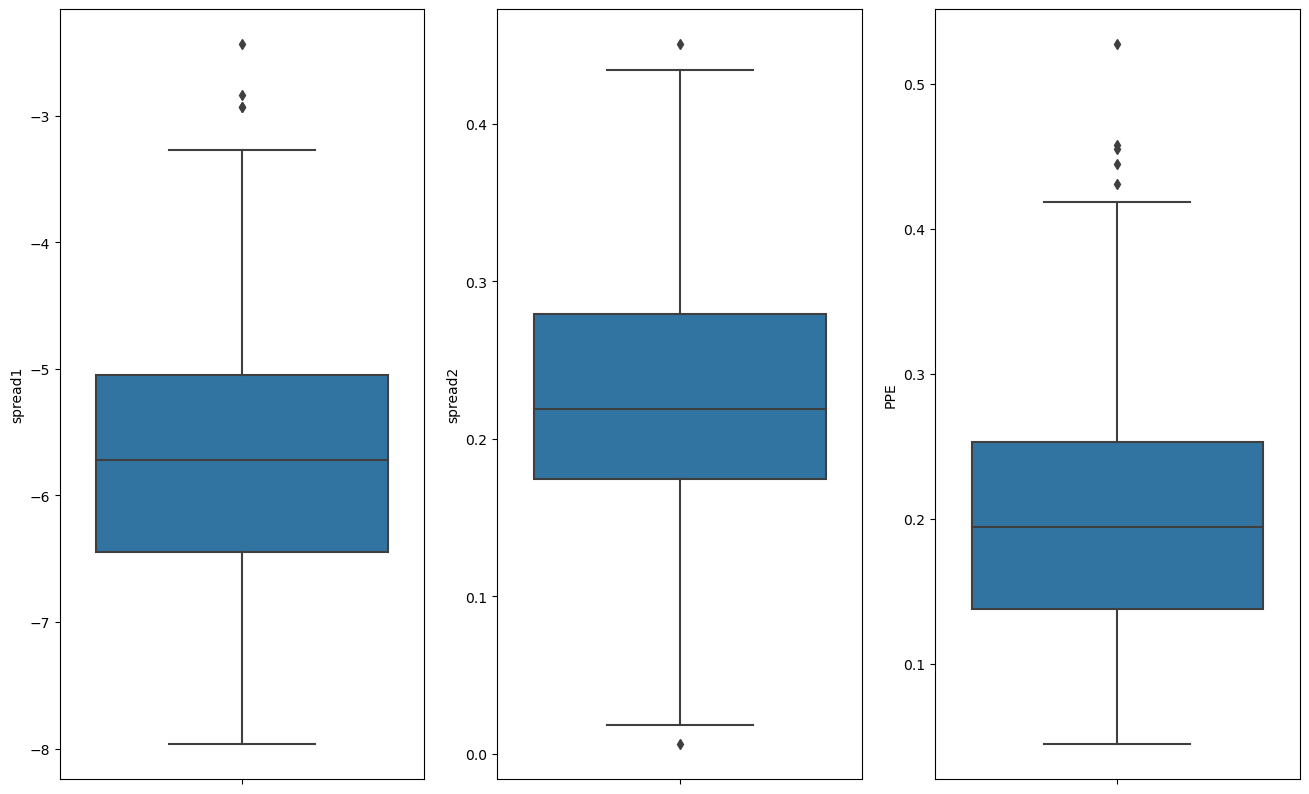

In [10]:
#Visualizing distribution of certain variables('spread1','spread2','PPE') using box plots
fig, ax = plt.subplots(1,3,figsize=(16,10)) 
sns.boxplot(y='spread1',data=data, ax=ax[0],orient='v') 
sns.boxplot(y='spread2',data=data, ax=ax[1],orient='v')
sns.boxplot(y='PPE',data=data,ax=ax[2],orient='v')

The above figure shows the box plot of the frequency variation. All the three variations have outliers. Generally speaking, decision trees are able to handle outliers. It is very unlikely that decision tree will create a leaf to isolate them

In [11]:
# dropping name column as this column is not much significant 
data = data.drop('name',axis=1)

<Axes: xlabel='MDVP:Fhi(Hz)', ylabel='Density'>

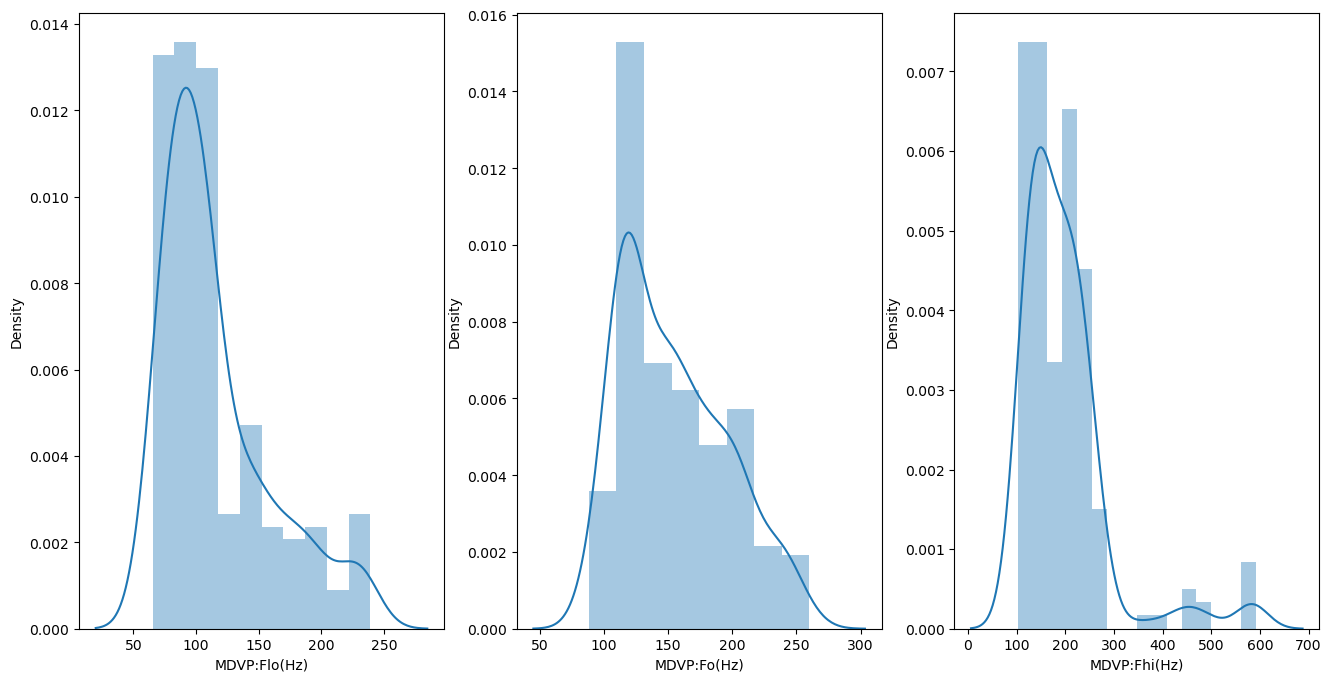

In [12]:
# Visualizing distribution of average, maximum and medium vocal frequency measures using density plots

fig, ax = plt.subplots(1,3,figsize=(16,8)) 
sns.distplot(data['MDVP:Flo(Hz)'],ax=ax[0]) #Low 
sns.distplot(data['MDVP:Fo(Hz)'],ax=ax[1])  #medium
sns.distplot(data['MDVP:Fhi(Hz)'],ax=ax[2]) #High

The measures of vocal fundamental frequency are shown above. There is a positive skewness for minimum vocal fundemental frequency with more high values between 75Hz and 125Hhz. The average vocal frequency is almost normally distributed with more values ranging 115Hz and 130Hz. The high vocal frequency does not have any skewness, but some range of values are at the right most tail

<Axes: xlabel='HNR', ylabel='Density'>

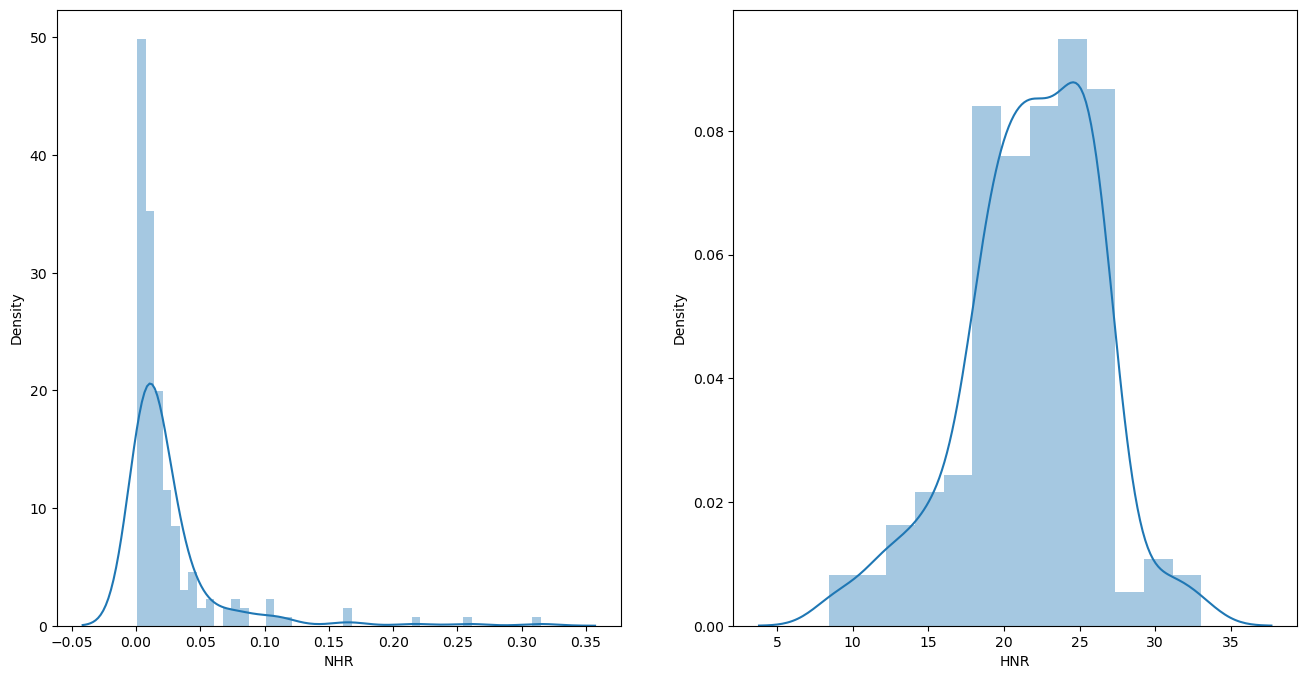

In [13]:
## Visualizing distribution of tonal component of frequency measures using density plots
fig, ax = plt.subplots(1,2,figsize=(16,8)) 
sns.distplot(data['NHR'],ax=ax[0]) 
sns.distplot(data['HNR'],ax=ax[1])

The measure of tonal component of frequency is shown above. The value NHR is right skewed for there are so many observations in the area, but they seem to be with very minimal values. The maximum number of observations is between 0 and 0.04. The value HNR looks like normally distributed, but in a first look there seems to be a slight negative skewness

<Axes: xlabel='Shimmer:DDA', ylabel='Density'>

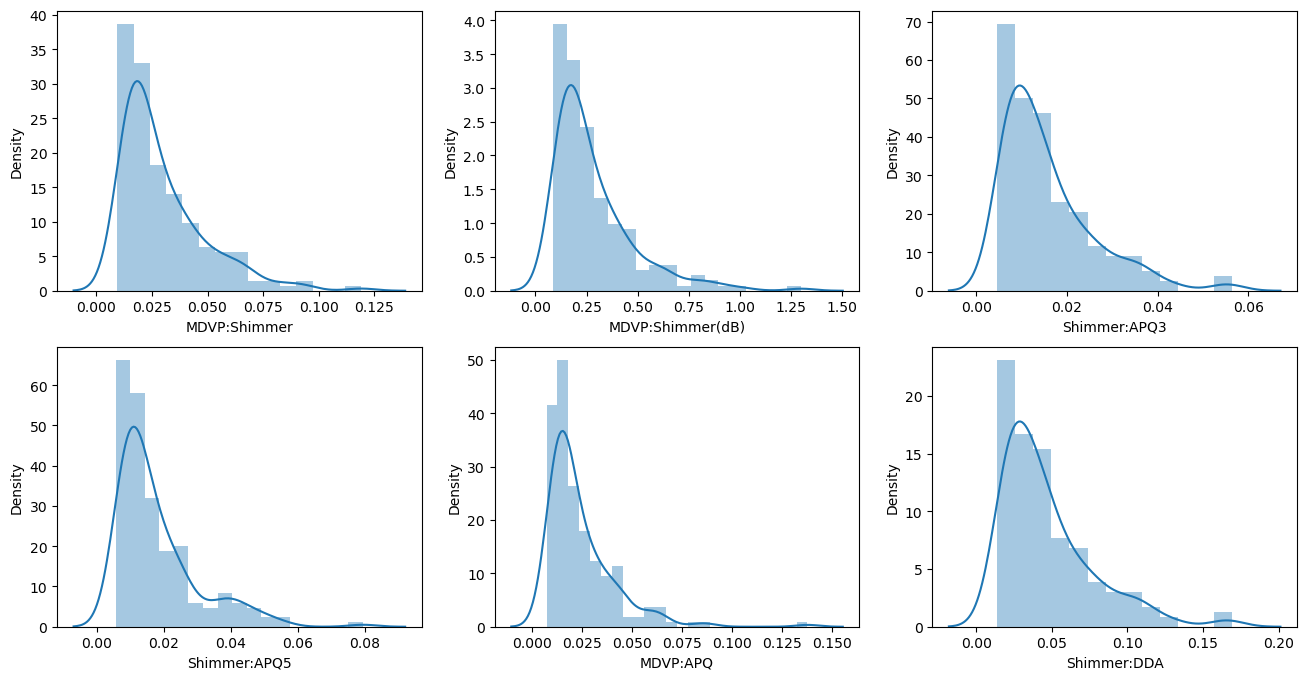

In [14]:
# Visualizing distribution of variation in amplitude measures using density plots

fig, ax = plt.subplots(2,3,figsize=(16,8)) 
sns.distplot(data['MDVP:Shimmer'],ax=ax[0,0]) 
sns.distplot(data['MDVP:Shimmer(dB)'],ax=ax[0,1]) 
sns.distplot(data['Shimmer:APQ3'],ax=ax[0,2]) 
sns.distplot(data['Shimmer:APQ5'],ax=ax[1,0]) 
sns.distplot(data['MDVP:APQ'],ax=ax[1,1]) 
sns.distplot(data['Shimmer:DDA'],ax=ax[1,2])

For all of the above graphs, we can observe that the measure of variation in amplitude is positively skewed

## Bi -Variate Analysis

<Axes: xlabel='spread1', ylabel='Density'>

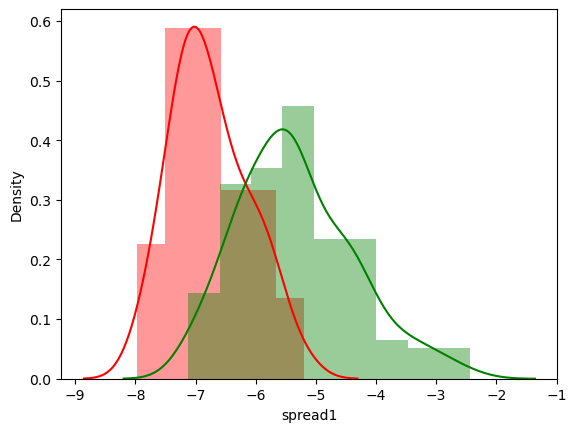

In [15]:
# Visualizing relationship between variable('spread1') and Parkinson's status using dist plots

sns.distplot( data[data.status == 0]['spread1'], color = 'r')
sns.distplot( data[data.status == 1]['spread1'], color = 'g')

 Spread1 is normally distributed between person who have PD and who is normal. People who have spread1 between - 8.5 and -7.5 are more and they are normal. People whose spread1 is between -6.5 and -5 are having PD

<Axes: xlabel='spread1', ylabel='Density'>

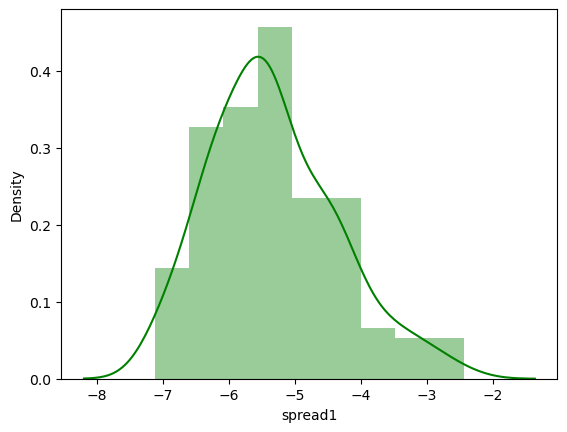

In [16]:
sns.distplot( data[data.status == 1]['spread1'], color = 'g')

<Axes: xlabel='status', ylabel='PPE'>

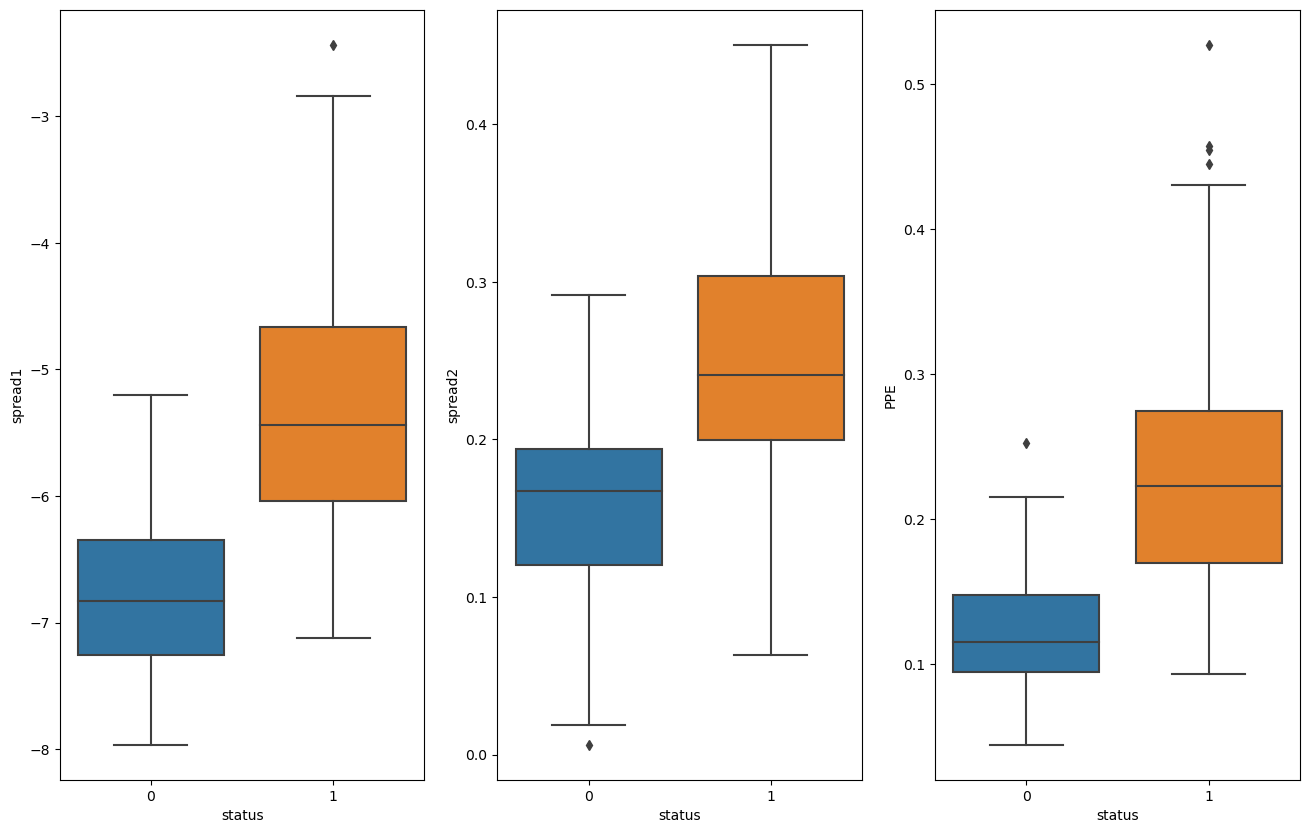

In [17]:
# Visualizing relationship between variable('spread1','spread2','PPE') and Parkinson's status using box plots

fig, ax = plt.subplots(1,3,figsize=(16,10)) 
sns.boxplot(y='spread1',x="status", data=data, ax=ax[0],orient='v') 
sns.boxplot(y='spread2',x="status", data=data, ax=ax[1],orient='v')
sns.boxplot(y='PPE',x="status", data=data,ax=ax[2],orient='v')

1. Form 1st box plot we can say the interquartile range of spread1 for normal people is aprox -8.8 to -7.6 on the other hand for diseased people it ranges from -6 to 5.3.
2. Form 2nd box plot we can say the interquartile range of spread2 for normal people is between 0.1 to 0.2 on the other hand for diseased people it ranges from 0.2-0.3. The box plot for both population is skewed. 
3. Form 3rd box plot we can say the interquartile range of PPE for normal people is between 0.0.9 to 0.15 on the other hand for diseased people it ranges from 0.17-0.28(aprox).

 We can conclude people with higher values of these 3 variables have PD and people with lower values are normal.

<Axes: xlabel='status', ylabel='HNR'>

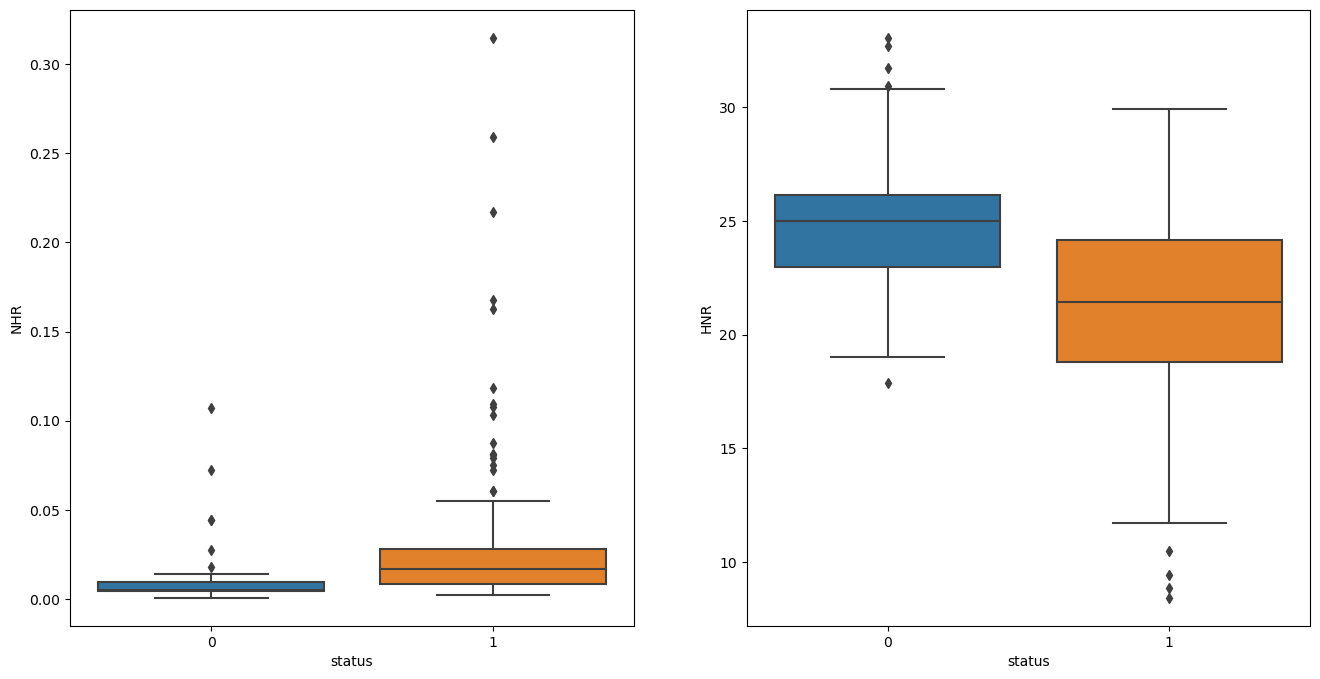

In [18]:
# Visualizing relationship between status and variables('NHR','HNR') using box plots
fig, ax = plt.subplots(1,2,figsize=(16,8))
sns.boxplot(x='status',y='NHR',data=data,ax=ax[0])
sns.boxplot(x='status',y='HNR',data=data,ax=ax[1])

1. Noise-to-Harmonics Ratio (NHR):NHR quantifies the amount of noise present in the voice signal relative to the harmonics.
    Higher values of NHR indicate a higher level of noise relative to the harmonic content, which may be indicative of voice disorders or irregularities.
2. Harmonics-to-Noise Ratio (HNR):HNR measures the ratio of harmonic energy to noise energy in the voice signal.
    Higher values of HNR indicate a stronger harmonic structure relative to noise, which is typically associated with clearer and more regular vocalization.
    
People who have PD have higher levels of NHR. Also, looking into the HNR ratio people who have PD have lower levels in the same.

<Axes: xlabel='status', ylabel='MDVP:Fo(Hz)'>

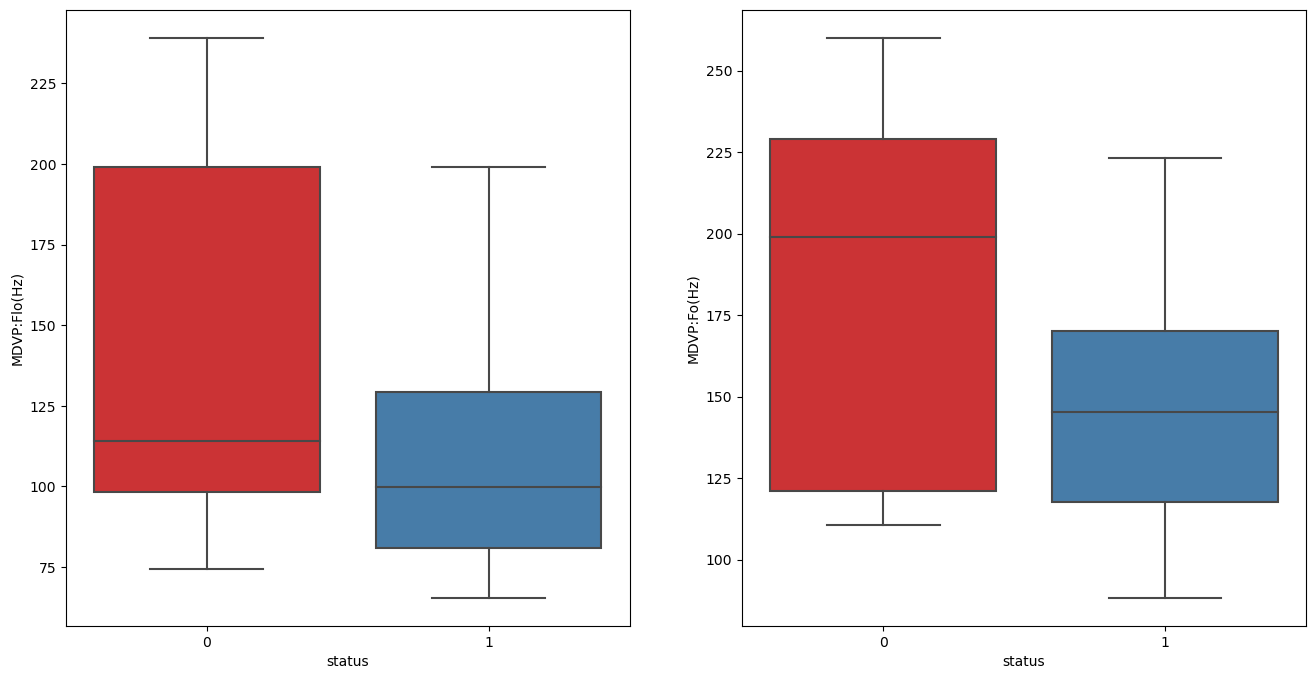

In [19]:
# Visualizing relationship between status and variables('MDVP:Flo(Hz)','MDVP:Fo(Hz)') using box plots
fig, ax = plt.subplots(1,2,figsize=(16,8))
sns.boxplot(x='status',y='MDVP:Flo(Hz)',data=data,palette="Set1",ax=ax[0])
sns.boxplot(x='status',y='MDVP:Fo(Hz)',data=data,palette="Set1",ax=ax[1])

1. When we look the relationship between status and MDVP:Flo(Hz) we can see the box plots are positively skewed. median value is around 150 Hz for people who are normal and around 100 for people who are diseased.
2. When we look the relationship between status and MDVP:Fo(Hz) we can see the median value is around 199 Hz for people who are normal. For people who are affected with Parkinsons the median value comes around 145 Hz

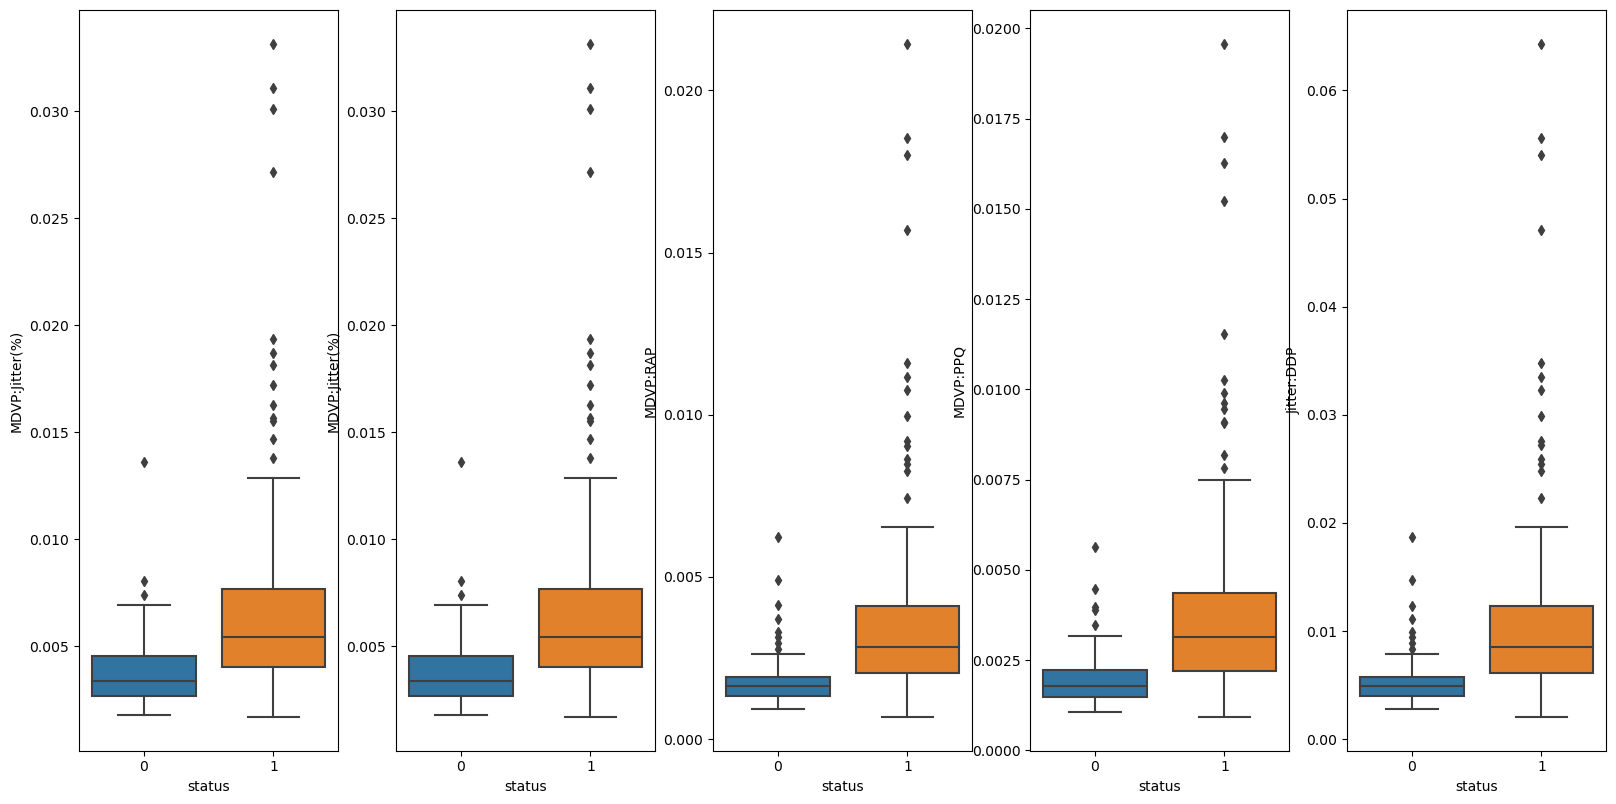

In [20]:
# For categorical predictors

#creating list named 'cols' with column names from the dataset which we will use to plot graph.
cols = ["MDVP:Jitter(%)","MDVP:Jitter(%)","MDVP:RAP","MDVP:PPQ","Jitter:DDP"]
fig, axs = plt.subplots(ncols = 5,figsize=(16,8))
fig.tight_layout()
# Loop through the columns and plot boxplots for each
for i in range(0,len(cols)):
    # Plot a boxplot for the ith column, grouped by the 'status' column
    # 'x' specifies the categorical variable ('status'), 'y' specifies the numerical variable (cols[i])
    # 'data' is the DataFrame containing the data
    # 'ax' specifies the current subplot to plot on.
    sns.boxplot(x='status',y=cols[i],data=data, ax = axs[i])

People who are suffering for PD tend to have higher jitter %. It seems if the values goes above 0.15 we can confirm the patient is having PD. The variation of fundamental frequency is in a low range for people who is normal.

## Correlation comparision with heat map

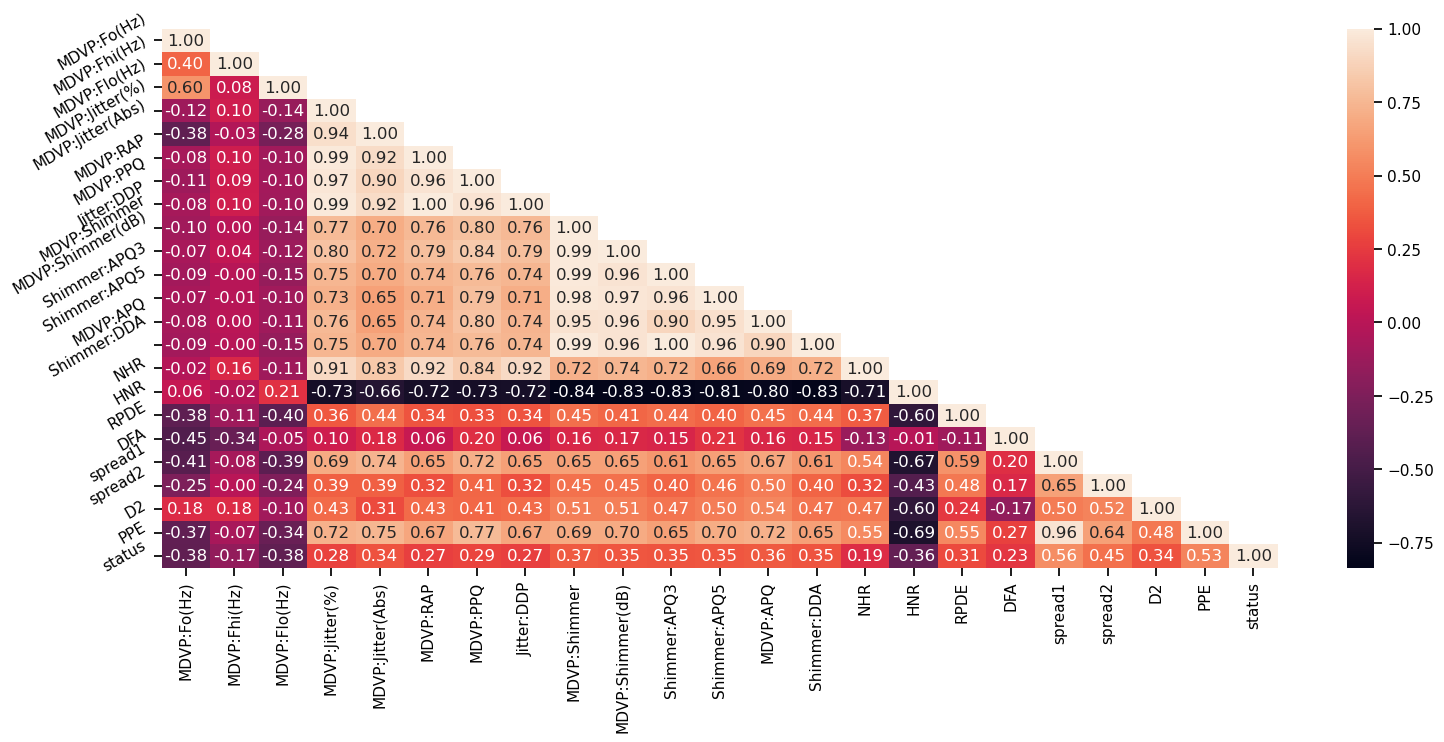

In [21]:
# Compute the correlation matrix for the DataFrame 'data'
corr = data.corr()

# Set the context for the plot (notebook), font scale, and line width
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 3.5})

# Create a new figure for the heatmap, specifying its size
plt.figure(figsize=(18,7))

# create a mask, which will hide the upper triangle of the correlation matrix, so we only see the correlation values once,
mask = np.zeros_like(corr) # Create an array of zeros with the same shape as 'corr'
mask[np.triu_indices_from(mask, 1)] = True# Set the upper triangle of the mask to True

# Generate a heatmap of the correlation matrix, using the mask to hide upper triangle,
# annotating the values on the heatmap with 2 decimal places
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')

# Rotate the x-axis labels by 90 degrees for better readability
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)

# Rotate the y-axis labels by 30 degrees for better readability
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

* MDVP:Jitter(%) has a very high correlation with MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP
* MDVP:Shimmer has a very correlation with MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA this may be because they are related to each other. This may be because multi-dimensinal voice programs analysis is closely related with these variables
* The target variable status has a weak positive corelation with spread1


## Applying Models

### Decision Tree

Decision trees can be used to predict both continuous and discrete values i.e. they work well for both regression and classification tasks.

In [22]:
from sklearn import metrics

In [23]:
# Extracting features (independent variables) by dropping the "status" column from the DataFrame
X = data.drop("status",axis=1)

# Extracting the target variable (dependent variable) by selecting only the "status" column from the DataFrame
Y = data["status"]


In [24]:
# Splitting Data into 70% Training data and 30% Testing Data:
X_train, X_test, y_train,  y_test = train_test_split(X, Y,train_size=0.7, test_size=0.3, random_state=42)
print(len(X_train)),print(len(X_test))

136
59


(None, None)

In [25]:
# Applying decision tree model
dt_model = DecisionTreeClassifier(criterion='entropy',max_depth=6,random_state=100,min_samples_leaf=5)

### Here we have created decession tree model.
1. Splitted Data into 70% Training data and 30% Testing Data.
2. created an instance, 'dt_model' of the DecisionTreeClassifier class from scikit-learn, which represents a decision tree classifier model.
3. The 'criterion' parameter is set to 'entropy', that means the model will use information gain to determine the best split.
4. The 'max_depth' parameter is set to 6, that means,the decision tree will be grown until it reaches a maximum depth of 6.So in this case the tree will have at most 6 levels of nodes (including the root node).
5. the 'random_state' parameter is set to 100.It ensures that the random number generation during the construction of the tree is consistent across runs.
6. The 'min_samples_leaf' parameter is set to 5. It means that each leaf node in the decision tree must contain at least 5 samples. This parameter helps prevent overfitting by imposing a constraint on the number of samples in each leaf node. 

In [27]:
#fitting decision tree model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=5,
                       random_state=100)

In [32]:
DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=6,
            max_features=None, max_leaf_nodes=None,min_samples_leaf=5,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
             random_state=100, splitter='best')

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=5,
                       random_state=100)

In [38]:
# Predicting labels for the test set using the trained decision tree model
y_pred = dt_model.predict(X_test)

In [39]:
# Calculating the accuracy of the model on the test set
dt_model.score(X_test , y_test) 

0.8983050847457628

In [40]:
# Generating a confusion matrix to evaluate the performance of the model
confusion_matrix(y_test,y_pred)

array([[11,  4],
       [ 2, 42]], dtype=int64)

In [37]:
#Count mis-classified one
count_misclassified = (y_test != y_pred).sum()
print('Misclassified samples: {}'.format(count_misclassified))

Misclassified samples: 6


In [41]:
# Print a DataFrame displaying the feature importances of the decision tree model

print (pd.DataFrame(dt_model.feature_importances_, columns = ["Imp"], index = X_train.columns))

                       Imp
MDVP:Fo(Hz)       0.113981
MDVP:Fhi(Hz)      0.196589
MDVP:Flo(Hz)      0.000000
MDVP:Jitter(%)    0.000000
MDVP:Jitter(Abs)  0.000000
MDVP:RAP          0.000000
MDVP:PPQ          0.000000
Jitter:DDP        0.000000
MDVP:Shimmer      0.000000
MDVP:Shimmer(dB)  0.073695
Shimmer:APQ3      0.000000
Shimmer:APQ5      0.000000
MDVP:APQ          0.000000
Shimmer:DDA       0.056276
NHR               0.000000
HNR               0.000000
RPDE              0.000000
DFA               0.000000
spread1           0.205876
spread2           0.000000
D2                0.000000
PPE               0.353584


From the DataFrame displaying feature importances, we can conclude that "PPE"  and "spread1" are the most influential features in the decision-making process of the model. These attributes contribute significantly to predicting the target variable. Meanwhile, "MDVP:Fo(Hz)" and "MDVP:Fhi(Hz)" also have noticeable importance,but to a lesser extent. Features such as "MDVP:Flo(Hz)" and "MDVP:Shimmer(dB)" have negligible importance, indicating minimal contribution to the model's predictions.







### K Nearest Neighbour

In [42]:
# Creating a KNeighborsClassifier model with 5 neighbor
k_model = KNeighborsClassifier(n_neighbors=5)

# Training the KNeighborsClassifier model on the training data
k_model.fit(X_train, y_train)

# Calculatinf the accuracy of the KNeighborsClassifier model on the test data
k_model.score(X_test,y_test)

0.8305084745762712

In [43]:
# Predicting labels for the test set using the trained KNeighborsClassifier model
y_pred = k_model.predict(X_test)


In [45]:
# Counting the number of misclassified samples by comparing predicted labels with true labels
count_misclassified = (y_test != y_pred).sum()

# Printing the number of misclassified samples for KNeighborsClassifier
print('Misclassified samples in KNN: {}'.format(count_misclassified))

Misclassified samples in KNN: 10


### Random Forest Classifier

In [46]:
# Importing the RandomForestClassifier class from the sklearn.ensemble module
from sklearn.ensemble import RandomForestClassifier

# Creating a RandomForestClassifier model with 50 decision trees (estimators)
rfcl = RandomForestClassifier(n_estimators = 50)

# Training (fitting) the RandomForestClassifier model on the training data
rfcl = rfcl.fit(X_train, y_train)

# Predicting labels for the test set using the trained RandomForestClassifier model
y_pred = rfcl.predict(X_test)

# Calculating the accuracy of the RandomForestClassifier model on the test data
rfcl.score(X_test , y_test)

0.9491525423728814

In [48]:
# Counting the number of misclassified samples by comparing predicted labels with true labels
count_misclassified = (y_test != y_pred).sum()

# Printing the number of misclassified samples for the RandomForestClassifier
print('Misclassified samples in Random Forest: {}'.format(count_misclassified))

Misclassified samples in Random Forest: 3


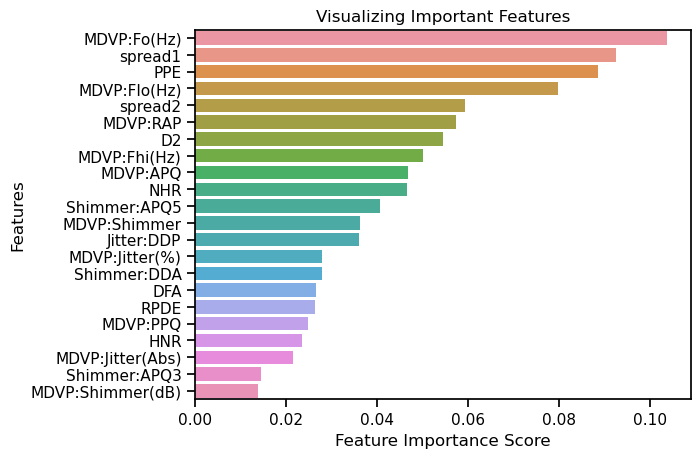

In [53]:
# Calculating feature importances and sorting them in descending order
feature_imp = pd.Series(rfcl.feature_importances_,index=X.columns).sort_values(ascending=False)
feature_imp
# Creating a bar plot
sns.barplot(x=feature_imp, y=feature_imp.index)
# Add labels to your graph
plt.xlabel('Feature Importance Score')# Label for x-axis
plt.ylabel('Features')# Label for x-axis
plt.title("Visualizing Important Features")# Title for the plot

# Displaying the plot
plt.show()

From the above barplot visualizing important features we can say:
1. Features such as "MDVP:Fo(Hz)" and "spread1" have relatively higher importance scores, indicating they play significant roles in the prediction process.
2. "PPE" and "MDVP:Flo(Hz)" also exhibit notable importance, suggesting their contribution to the predictive power of the model.
3. Less influential features include "spread2", "MDVP:RAP", and "D2", which have lower importance scores compared to the top features.
4. Features like "MDVP:Shimmer" and "MDVP:Jitter(%)" have relatively lower importance, indicating they contribute less to the overall predictive performance of the model.
5. Some features, such as "Shimmer:APQ3" and "MDVP:Shimmer(dB)", have the lowest importance scores, suggesting they have minimal impact on the model's predictions.

### Bagging

In [55]:
# Importing the BaggingClassifier class from the sklearn.ensemble module
from sklearn.ensemble import BaggingClassifier

# Creating an instance,'bgcl' of BaggingClassifier class, with Decision Tree as base estimator, 50 estimators, and sampling 70% of the training data
bgcl = BaggingClassifier(base_estimator=dt_model, n_estimators=50, max_samples=.7)

# Training (fitting) the 'bgcl' model on the training data
bgcl = bgcl.fit(X_train, y_train)

# Predicting labels for the test set using the trained 'bgcl' model
y_pred = bgcl.predict(X_test)

# Calculating the accuracy of the model on the test data
bgcl.score(X_test , y_test)

C:\Users\soumi\anaconda3\lib\site-packages\sklearn\ensemble\_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


0.9152542372881356

In [56]:
# Counting the number of misclassified samples by comparing predicted labels with true labels
count_misclassified = (y_test != y_pred).sum()

# Printing the number of misclassified samples for the BaggingClassifier
print('Misclassified samples in Bagging: {}'.format(count_misclassified))

Misclassified samples in Bagging: 5


### AdaBoosting

AdaBoost, or Adaptive Boosting, is a powerful ensemble learning method that combines multiple weak learners into a strong classifier. It iteratively trains weak models, focusing more on instances that were previously misclassified. By adjusting weights on training samples, AdaBoost prioritizes difficult-to-classify examples, gradually improving overall performance. Each weak learner contributes to the final prediction through a weighted vote, resulting in a robust and accurate ensemble model. AdaBoost is widely used in classification tasks and is known for its ability to handle complex datasets and improve generalization.


In [57]:
from sklearn.ensemble import AdaBoostClassifier
abcl = AdaBoostClassifier( n_estimators= 50)
abcl = abcl.fit(X_train,y_train)
y_pred = abcl.predict(X_test)
abcl.score(X_test , y_test)

0.8983050847457628

In [58]:
count_misclassified = (y_test != y_pred).sum()
print('Misclassified samples in Ada Boosting: {}'.format(count_misclassified))

Misclassified samples in Ada Boosting: 6


### Gradient Boosting

Gradient Boosting is an ensemble learning technique that sequentially trains a series of weak learners, such as decision trees, to correct the errors made by the previous models. It works by minimizing a specified loss function, such as mean squared error or mean absolute error, using gradient descent optimization. At each iteration, the next weak learner is trained on the residuals (the differences between the true values and the predictions) of the previous model. By iteratively improving upon the weaknesses of the preceding models, Gradient Boosting constructs a strong predictive model that can handle complex datasets and achieve high accuracy

In [59]:
from sklearn.ensemble import GradientBoostingClassifier
gbcl = GradientBoostingClassifier(n_estimators = 50, learning_rate = 0.05)
gbcl = gbcl.fit(X_train,y_train)
y_pred = gbcl.predict(X_test)
gbcl.score(X_test , y_test)

0.8983050847457628

In [60]:
count_misclassified = (y_test != y_pred).sum()
print('Misclassified samples in Gradient Boosting: {}'.format(count_misclassified))

Misclassified samples in Gradient Boosting: 6


Of all the above ones Random Forest algorithm gave the maximum accuracy